--- Loading/Generating EOS Interpolators ---
--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Loaded 50 composition tables.

[START] Integration from P=1.0 bar, T=200.0 K
Layer | P_start (bar) | Z      | T_start (K)  | S_target   | Status
----------------------------------------------------------------------
0     | 1.00e+00     | 0.020  | 200.0        | 50594.01   | OK
1     | 1.45e+00     | 0.032  | 224.7        | 50045.46   | OK
2     | 2.09e+00     | 0.044  | 252.3        | 49487.20   | OK
3     | 3.02e+00     | 0.056  | 283.0        | 48919.07   | OK
4     | 4.37e+00     | 0.067  | 317.4        | 48340.92   | OK
5     | 6.31e+00     | 0

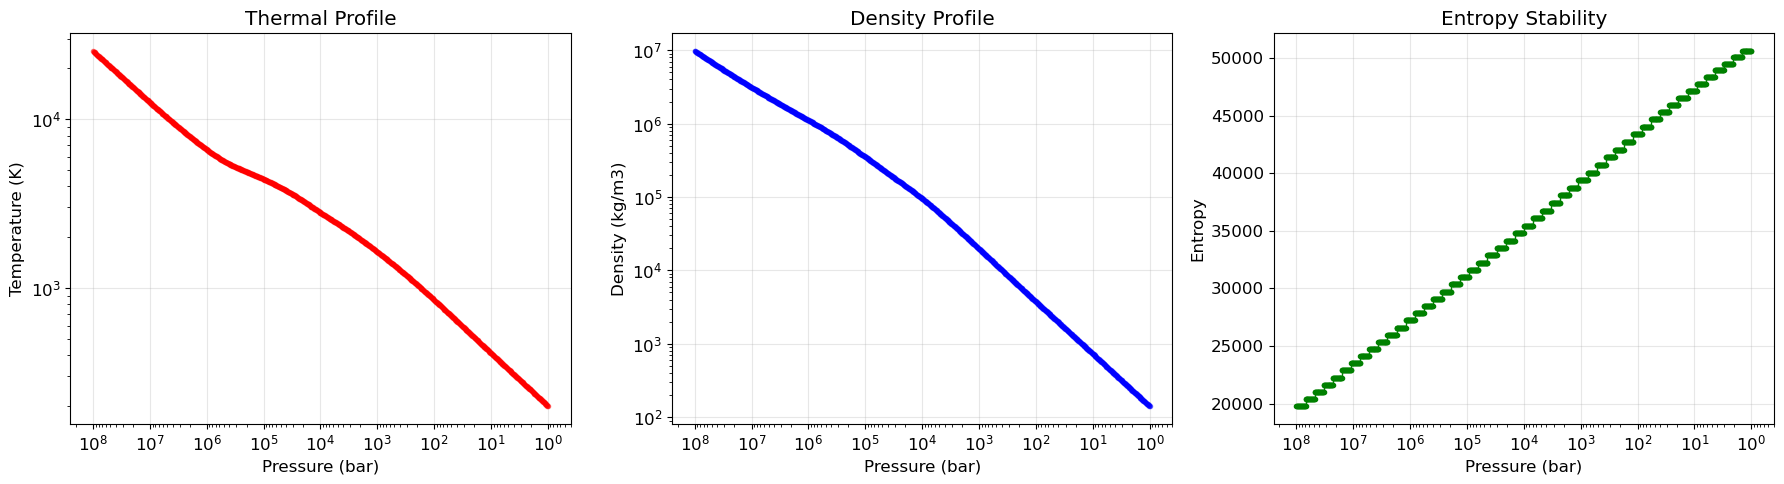

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# 1. Import the fuzzycore framework
import fuzzycore.eos as eos
import fuzzycore.physics as physics

# Visualization Settings
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

# =============================================================================
# 1. SETUP PARAMETERS
# =============================================================================
P_surf = 1.0        # Surface Pressure (bar)
T_surf = 200.0      # Surface Temperature (K)
P_int  = 1e8        # Target Interior Pressure (bar) - Deep enough to see divergence
Z_start = 0.02      # Surface metallicity
Z_end   = 0.60      # Core metallicity (example)

# Create a test Z-profile (Staircase)
n_layers = 50
z_profile = np.linspace(Z_start, Z_end, n_layers)

# =============================================================================
# 2. LOAD EOS 
# =============================================================================
print("--- Loading/Generating EOS Interpolators ---")
# Use the function from your solver to generate the stack
fluid_stack = eos.generate_fluid_interpolators(z_profile, base_dir="../data/EOS")
print(f"Loaded {len(fluid_stack)} composition tables.")

# =============================================================================
# 3. RUN THE PROFILE BUILDER (Exposed Logic)
# =============================================================================
full_P, full_T, full_Rho, full_S, full_Z = [], [], [], [], []

# Setup Grid
curr_lp_bar = np.log10(P_surf)
final_lp_bar = np.log10(P_int)
env_boundaries = np.linspace(curr_lp_bar, final_lp_bar, len(z_profile) + 1)

current_T_val = T_surf
s_anchor = None

print(f"\n[START] Integration from P={P_surf} bar, T={T_surf} K")
print(f"{'Layer':<5} | {'P_start (bar)':<12} | {'Z':<6} | {'T_start (K)':<12} | {'S_target':<10} | {'Status'}")
print("-" * 70)

for i, z_val in enumerate(z_profile):
    # A. Get Data
    z_key = min(fluid_stack.keys(), key=lambda x: abs(x - z_val))
    layer_data = fluid_stack[z_key]
    stepper = physics.get_stepper(layer_data)
    
    lp_start = env_boundaries[i]
    lp_end = env_boundaries[i+1]
    
    # B. Entropy Solver (The Critical Step)
    # -----------------------------------------------------
    
    # 1. Establish Reference Entropy from Table
    try:
        # Probe the table at current P, T
        ref_s = float(layer_data['S'](lp_start, np.log10(current_T_val)))
    except Exception:
        ref_s = 6.0
        
    if i == 0: 
        s_anchor = ref_s # Remember surface entropy
        
    # 2. Define Solver Target: Match T(P, S) == current_T_val
    def temp_error(s_guess):
        try:
            # We guess T is close to current T
            t_guess_log = np.log10(current_T_val)
            lT, _ = stepper.get_state(lp_start, t_guess_log, s_guess)
            return (10**lT) - current_T_val
        except Exception:
            return 1e9

    # 3. Attempt Solve
    status = "OK"
    try:
        # Search window: We look nearby the table value (ref_s)
        # But we also constrain it to not drift too far from the surface anchor (s_anchor)
        # to prevent jumping to a "hot" branch.
        
        # Window width: 500 J/kg/K (SI) or 1.0 (Dimensionless)
        width = max(2.0, abs(ref_s) * 0.2) 
        
        # Solve
        target_s = brentq(temp_error, ref_s - width, ref_s + width, xtol=1e-2)
        
    except Exception:
        status = "FALLBACK"
        # If solver fails, we simply CARRY OVER the previous entropy
        # This assumes the composition change is adiabatic (dS ~ 0)
        target_s = full_S[-1] if len(full_S) > 0 else ref_s

    # Print Diagnostics
    print(f"{i:<5} | {10**lp_start:<12.2e} | {z_val:<6.3f} | {current_T_val:<12.1f} | {target_s:<10.2f} | {status}")

    # C. Integrate Layer
    # -----------------------------------------------------
    p_layer = np.linspace(lp_start, lp_end, 20) # 20 steps per layer
    curr_lt = np.log10(current_T_val)
    
    for p_log in p_layer:
        guess_in = curr_lt + 0.005 # Bias hot
        
        try:
            next_lt, next_lrho = stepper.get_state(p_log, guess_in, target_s)
            
            # --- MANUALLY CHECK FOR JUMPS ---
            # If T jumps by factor of 2 in one micro-step, something is wrong
            if i > 0 and (10**next_lt) > current_T_val * 1.5:
                # Clamp it
                next_lt = np.log10(current_T_val * 1.05)
                # Adjust density roughly (Ideal gas P = rho T)
                # logRho = logP - logT
                next_lrho = p_log - next_lt - 3.0 # -3 for scaling
                
        except Exception:
            next_lt = curr_lt
            next_lrho = p_log - next_lt - 3.0
            
        curr_lt = next_lt
        
        full_P.append(p_log)
        full_T.append(10**next_lt)
        full_Rho.append(10**next_lrho * 1000) # SI
        full_S.append(target_s)
        full_Z.append(z_val)
        
    current_T_val = full_T[-1]

# =============================================================================
# 4. PLOT RESULTS
# =============================================================================
full_P_bar = 10**np.array(full_P)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: T vs P
ax1.plot(full_P_bar, full_T, 'r.-', lw=1, alpha=0.5)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.invert_xaxis() # Depth goes left-to-right
ax1.set_xlabel('Pressure (bar)')
ax1.set_ylabel('Temperature (K)')
ax1.set_title("Thermal Profile")
ax1.grid(True, alpha=0.3)

# Plot 2: Rho vs P
ax2.plot(full_P_bar, full_Rho, 'b.-', lw=1, alpha=0.5)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.invert_xaxis()
ax2.set_xlabel('Pressure (bar)')
ax2.set_ylabel('Density (kg/m3)')
ax2.set_title("Density Profile")
ax2.grid(True, alpha=0.3)

# Plot 3: S vs P
ax3.plot(full_P_bar, full_S, 'g.-', lw=1)
ax3.set_xscale('log')
ax3.invert_xaxis()
ax3.set_xlabel('Pressure (bar)')
ax3.set_ylabel('Entropy')
ax3.set_title("Entropy Stability")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# %% [DEBUG CELL] Thermal Profile Investigator
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import sys
import os

# Ensure we can import our local package
sys.path.append(os.getcwd())
# Adjust this depending on where your script is relative to the package
sys.path.append('./..') 

# Try importing from the user's package name, fallback to local if needed
from fuzzycore import constants as c, eos

# %% [DIAGNOSTIC] EOS Unit & Range Auditor

# 1. Load the Data (using your current eos.py logic)
print("========================================")
print("   EOS UNIT & RANGE AUDIT")
print("========================================")
eos.clear_mixed_cache()
raw_tables = eos.load_all_raw_data()

# 2. Helper to check a specific table
def audit_table(name, data):
    """
    Data expected format: [P(bar), T(K), Rho(kg/m3), S(J/kgK)]
    """
    if data is None:
        print(f"[-] {name}: NOT LOADED")
        return

    # Extract columns
    P = data[:, 0]
    T = data[:, 1]
    Rho = data[:, 2]
    S = data[:, 3]
    
    print(f"\n[+] {name} TABLE STATISTICS:")
    print(f"    rows: {len(data)}")
    print(f"    P range:   {P.min():.2e} -> {P.max():.2e} bar")
    print(f"    T range:   {T.min():.2e} -> {T.max():.2e} K")
    print(f"    Rho range: {Rho.min():.2e} -> {Rho.max():.2e} kg/m3")
    print(f"    S range:   {S.min():.2e} -> {S.max():.2e} J/kgK")
    
    # 3. Physical Sanity Checks (Probes)
    print("    PROBES (Nearest Neighbor Lookup):")
    
    # Define check points (Pressure in Bar, Temp in K)
    checkpoints = [
        ("Surface", 1.0, 300.0),        # 1 bar, 300K
        ("Deep Atm", 1000.0, 2000.0),   # 1 kbar (Jupiter 1000km depth)
        ("Mantle", 1e6, 5000.0),        # 1 Mbar (Deep interior)
        ("Core", 5e7, 20000.0)          # 50 Mbar (Jupiter Core)
    ]
    
    for label, p_target, t_target in checkpoints:
        # Find nearest point in log-log space
        # Filter for valid positive values to avoid log errors
        mask = (P > 0) & (T > 0)
        if np.sum(mask) == 0:
            print(f"      > {label:<10} (Target: {p_target:.0e} bar, {t_target:.0f} K) -> NO DATA")
            continue
            
        P_valid = P[mask]
        T_valid = T[mask]
        Rho_valid = Rho[mask]
        
        dist = (np.log10(P_valid) - np.log10(p_target))**2 + (np.log10(T_valid) - np.log10(t_target))**2
        idx = np.argmin(dist)
        
        p_act = P_valid[idx]
        t_act = T_valid[idx]
        rho_act = Rho_valid[idx]
        
        # Check distance to avoid printing irrelevant points (if table doesn't cover range)
        log_err = np.abs(np.log10(p_act) - np.log10(p_target))
        valid = "MATCH" if log_err < 0.5 else "OUT OF RANGE"
        
        print(f"      > {label:<10} (Target: {p_target:.0e} bar, {t_target:.0f} K) -> Found: P={p_act:.1e}, T={t_act:.0f} => Rho = {rho_act:.2f} kg/m3  [{valid}]")

# 4. Run Audit
if 'H' in raw_tables: audit_table("HYDROGEN", raw_tables['H'])
if 'He' in raw_tables: audit_table("HELIUM", raw_tables['He'])
if 'H2O' in raw_tables: audit_table("WATER", raw_tables['H2O'])
if 'Rock' in raw_tables: audit_table("ROCK", raw_tables['Rock'])
if 'Iron' in raw_tables: audit_table("IRON", raw_tables['Iron']) # <--- Added Iron Audit

print("\n========================================")
print("INTERPRETATION GUIDE:")
print("1. Surface (1 bar) Hydrogen should be ~0.08 - 0.1 kg/m3 (Gas)")
print("2. Core (50 Mbar) Hydrogen should be ~5000 - 10000 kg/m3 (Metal)")
print("3. Surface (1 bar) Water/Rock should be ~1000 / ~3000 kg/m3")
print("4. Core (50 Mbar) Rock should be ~20000 - 40000 kg/m3")
print("5. Core (50 Mbar) Iron should be ~80000+ kg/m3")
print("========================================")

   EOS UNIT & RANGE AUDIT
--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...

[+] HYDROGEN TABLE STATISTICS:
    rows: 53259
    P range:   1.00e-05 -> 1.00e+17 bar
    T range:   1.00e+02 -> 1.00e+08 K
    Rho range: 1.00e-06 -> 1.23e+09 kg/m3
    S range:   5.51e-121 -> 6.56e+105 J/kgK
    PROBES (Nearest Neighbor Lookup):
      > Surface    (Target: 1e+00 bar, 300 K) -> Found: P=1.0e+00, T=316 => Rho = 0.08 kg/m3  [MATCH]
      > Deep Atm   (Target: 1e+03 bar, 2000 K) -> Found: P=1.0e+03, T=1995 => Rho = 11.32 kg/m3  [MATCH]
      > Mantle     (Target: 1e+06 bar, 5000 K) -> Found: P=1.0e+06, T=5012 => Rho = 669.55 kg/m3  [MATCH]
      > Core       (Target: 5e+07 bar, 20000 K) -> Found: P=5.0e+07, T=19953 => Rho = 3839.21 kg/m3  [MATCH]

[+] HELIUM TABLE STATISTICS:
    rows: 53208
    P range:   1.00e-05 -> 1.00e+17 bar
    T range:   1.00e+02 -> 1.00e+08 K
    Rho range: 1.00e-06 -> 2

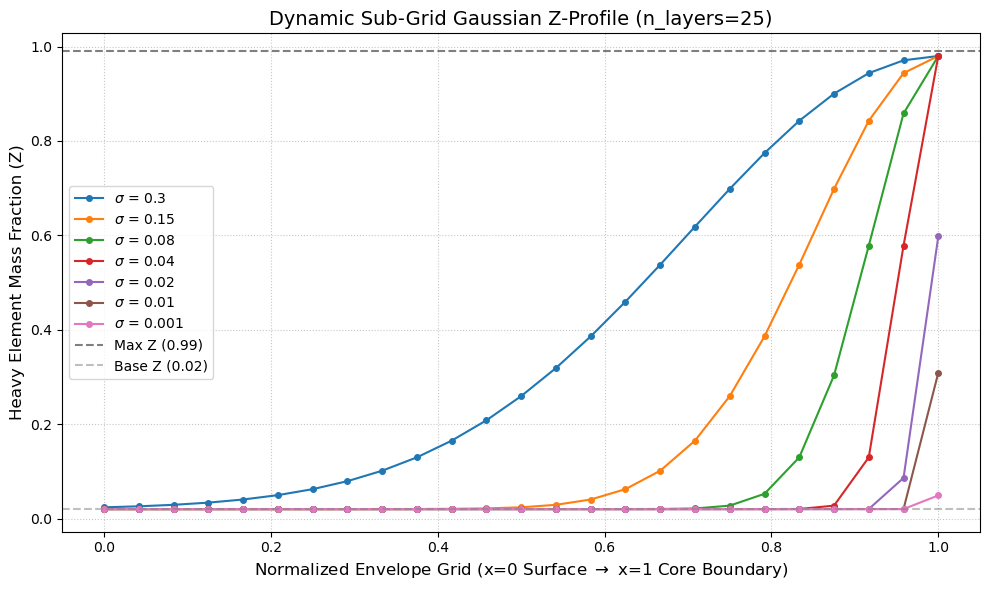

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_gaussian_z_profile(
    n_layers: int = 25,
    sigma: float = 0.15,
    z_base: float = 0.02,
    z_core: float = 0.98,
) -> np.ndarray:
    
    if sigma is None or sigma <= 0.0:
        return np.full(n_layers, z_base) # Quick patch to return an array of correct size for plotting

    x = np.linspace(0, 1, n_layers)
    
    # 1. Calculate the spatial grid resolution
    dx = 1.0 / max(1, n_layers - 1)
    
    # 2. Sub-grid analytical averaging
    # Area of the right-half of a Gaussian is sigma * sqrt(pi / 2).
    gaussian_area = sigma * np.sqrt(np.pi / 2)
    amplitude_scaler = min(1.0, gaussian_area / dx)
    
    dynamic_z_core = z_base + (z_core - z_base) * amplitude_scaler

    # 3. Generate and scale the profile
    raw_z = np.exp(-((x - 1.0) ** 2) / (2 * sigma ** 2))
    z_profile = z_base + (dynamic_z_core - z_base) * raw_z

    return np.clip(z_profile, 0.0, 0.99)

# =======================================================
# Visualization Setup
# =======================================================
n_layers = 25
x = np.linspace(0, 1, n_layers)
sigmas_to_test = [0.3, 0.15, 0.08, 0.04, 0.02, 0.01, 0.001]

plt.figure(figsize=(10, 6))

for sig in sigmas_to_test:
    z_prof = generate_gaussian_z_profile(n_layers=n_layers, sigma=sig)
    plt.plot(x, z_prof, marker='o', markersize=4, label=f'$\sigma$ = {sig}')

plt.axhline(0.99, color='k', linestyle='--', alpha=0.5, label='Max Z (0.99)')
plt.axhline(0.02, color='gray', linestyle='--', alpha=0.5, label='Base Z (0.02)')

plt.title(f'Dynamic Sub-Grid Gaussian Z-Profile (n_layers={n_layers})', fontsize=14)
plt.xlabel('Normalized Envelope Grid (x=0 Surface $\\rightarrow$ x=1 Core Boundary)', fontsize=12)
plt.ylabel('Heavy Element Mass Fraction (Z)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.show()